# **Assignment No. 3**

**Submitters:**

Topaz Aakal, 318644549

Tom Hilton, 318780343



---



# Machine Learning with PyTorch and Scikit-Learn  
# -- Code Examples

## Package version checks

Add folder to path in order to load from the check_packages.py script:

In [ ]:
import sys
sys.path.insert(0, '..')

Check recommended package versions:

In [ ]:
from python_environment_check import check_packages


d = {
    'numpy': '1.21.2',
    'matplotlib': '3.4.3',
    'sklearn': '1.0',
}
check_packages(d)

ModuleNotFoundError: No module named 'python_environment_check'

# Chapter 11 - Implementing a Multi-layer Artificial Neural Network from Scratch


### Overview

- [Modeling complex functions with artificial neural networks](#Modeling-complex-functions-with-artificial-neural-networks)
  - [Single-layer neural network recap](#Single-layer-neural-network-recap)
  - [Introducing the multi-layer neural network architecture](#Introducing-the-multi-layer-neural-network-architecture)
  - [Activating a neural network via forward propagation](#Activating-a-neural-network-via-forward-propagation)
- [Classifying handwritten digits](#Classifying-handwritten-digits)
  - [Obtaining the MNIST dataset](#Obtaining-the-MNIST-dataset)
  - [Implementing a multi-layer perceptron](#Implementing-a-multi-layer-perceptron)
  - [Coding the neural network training loop](#Coding-the-neural-network-training-loop)
  - [Evaluating the neural network performance](#Evaluating-the-neural-network-performance)
- [Training an artificial neural network](#Training-an-artificial-neural-network)
  - [Computing the loss function](#Computing-the-loss-function)
  - [Developing your intuition for backpropagation](#Developing-your-intuition-for-backpropagation)
  - [Training neural networks via backpropagation](#Training-neural-networks-via-backpropagation)
- [Convergence in neural networks](#Convergence-in-neural-networks)
- [Summary](#Summary)

<br>
<br>

In [ ]:
from IPython.display import Image
%matplotlib inline

# Modeling complex functions with artificial neural networks

...

## Single-layer neural network recap

In [ ]:
Image(filename='figures/11_01.png', width=600)

FileNotFoundError: [Errno 2] No such file or directory: 'figures/11_01.png'

<br>
<br>

## Introducing the multi-layer neural network architecture

In [ ]:
Image(filename='figures/11_02.png', width=600)

In [ ]:
Image(filename='figures/11_03.png', width=500)

<br>
<br>

## Activating a neural network via forward propagation

<br>
<br>

# Classifying handwritten digits

...

## Obtaining and preparing the MNIST dataset

The MNIST dataset is publicly available at http://yann.lecun.com/exdb/mnist/ and consists of the following four parts:

- Training set images: train-images-idx3-ubyte.gz (9.9 MB, 47 MB unzipped, 60,000 examples)
- Training set labels: train-labels-idx1-ubyte.gz (29 KB, 60 KB unzipped, 60,000 labels)
- Test set images: t10k-images-idx3-ubyte.gz (1.6 MB, 7.8 MB, 10,000 examples)
- Test set labels: t10k-labels-idx1-ubyte.gz (5 KB, 10 KB unzipped, 10,000 labels)



In [ ]:
from sklearn.datasets import fetch_openml


X, y = fetch_openml('mnist_784', version=1, return_X_y=True)
X = X.values
y = y.astype(int).values

print(X.shape)
print(y.shape)

(70000, 784)
(70000,)


Normalize to [-1, 1] range:

In [ ]:
X = ((X / 255.) - .5) * 2

Visualize the first digit of each class:

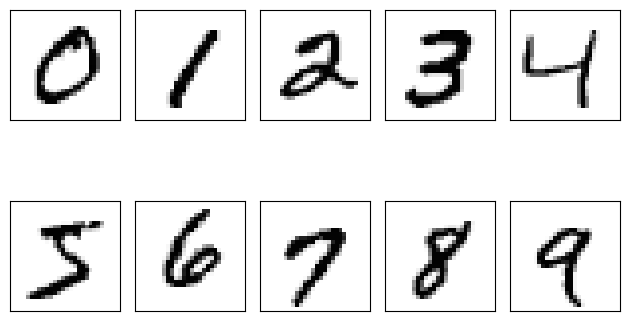

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(nrows=2, ncols=5, sharex=True, sharey=True)
ax = ax.flatten()
for i in range(10):
    img = X[y == i][0].reshape(28, 28)
    ax[i].imshow(img, cmap='Greys')

ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()
#plt.savefig('figures/11_4.png', dpi=300)
plt.show()

Visualize 25 different versions of "7":

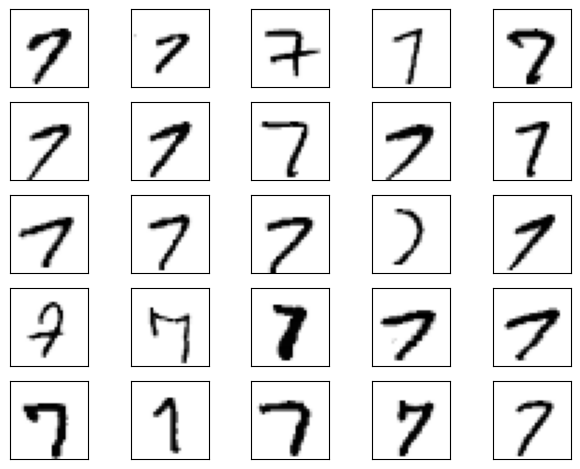

In [ ]:
fig, ax = plt.subplots(nrows=5, ncols=5, sharex=True, sharey=True)
ax = ax.flatten()
for i in range(25):
    img = X[y == 7][i].reshape(28, 28)
    ax[i].imshow(img, cmap='Greys')

ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()
# plt.savefig('figures/11_5.png', dpi=300)
plt.show()

Split into training, validation, and test set:

In [ ]:
from sklearn.model_selection import train_test_split

#change  test size for both times used train test spilt to 70% train, 30% test like asked in the question.
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.3, random_state=123, stratify=y)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp, y_temp, test_size=0.3, random_state=123, stratify=y_temp)


# optional to free up some memory by deleting non-used arrays:
del X_temp, y_temp, X, y

<br>
<br>

## Implementing a multi-layer perceptron

In [ ]:
import numpy as np

In [ ]:
##########################
### MODEL
##########################

def sigmoid(z):
    return 1. / (1. + np.exp(-z))


def int_to_onehot(y, num_labels):

    ary = np.zeros((y.shape[0], num_labels))
    for i, val in enumerate(y):
        ary[i, val] = 1

    return ary


class NeuralNetMLP:

    def __init__(self, num_features, num_hidden, num_classes, random_seed=123):
        super().__init__()

        self.num_classes = num_classes

        # hidden
        rng = np.random.RandomState(random_seed)

        self.weight_h = rng.normal(
            loc=0.0, scale=0.1, size=(num_hidden, num_features))
        self.bias_h = np.zeros(num_hidden)

        # output
        self.weight_out = rng.normal(
            loc=0.0, scale=0.1, size=(num_classes, num_hidden))
        self.bias_out = np.zeros(num_classes)

    def forward(self, x):
        # Hidden layer
        # input dim: [n_examples, n_features] dot [n_hidden, n_features].T
        # output dim: [n_examples, n_hidden]
        z_h = np.dot(x, self.weight_h.T) + self.bias_h
        a_h = sigmoid(z_h)

        # Output layer
        # input dim: [n_examples, n_hidden] dot [n_classes, n_hidden].T
        # output dim: [n_examples, n_classes]
        z_out = np.dot(a_h, self.weight_out.T) + self.bias_out
        a_out = sigmoid(z_out)
        return a_h, a_out

    def backward(self, x, a_h, a_out, y):

        #########################
        ### Output layer weights
        #########################

        # onehot encoding
        y_onehot = int_to_onehot(y, self.num_classes)

        # Part 1: dLoss/dOutWeights
        ## = dLoss/dOutAct * dOutAct/dOutNet * dOutNet/dOutWeight
        ## where DeltaOut = dLoss/dOutAct * dOutAct/dOutNet
        ## for convenient re-use

        # input/output dim: [n_examples, n_classes]
        d_loss__d_a_out = 2.*(a_out - y_onehot) / y.shape[0]

        # input/output dim: [n_examples, n_classes]
        d_a_out__d_z_out = a_out * (1. - a_out) # sigmoid derivative

        # output dim: [n_examples, n_classes]
        delta_out = d_loss__d_a_out * d_a_out__d_z_out # "delta (rule) placeholder"

        # gradient for output weights

        # [n_examples, n_hidden]
        d_z_out__dw_out = a_h

        # input dim: [n_classes, n_examples] dot [n_examples, n_hidden]
        # output dim: [n_classes, n_hidden]
        d_loss__dw_out = np.dot(delta_out.T, d_z_out__dw_out)
        d_loss__db_out = np.sum(delta_out, axis=0)


        #################################
        # Part 2: dLoss/dHiddenWeights
        ## = DeltaOut * dOutNet/dHiddenAct * dHiddenAct/dHiddenNet * dHiddenNet/dWeight

        # [n_classes, n_hidden]
        d_z_out__a_h = self.weight_out

        # output dim: [n_examples, n_hidden]
        d_loss__a_h = np.dot(delta_out, d_z_out__a_h)

        # [n_examples, n_hidden]
        d_a_h__d_z_h = a_h * (1. - a_h) # sigmoid derivative

        # [n_examples, n_features]
        d_z_h__d_w_h = x

        # output dim: [n_hidden, n_features]
        d_loss__d_w_h = np.dot((d_loss__a_h * d_a_h__d_z_h).T, d_z_h__d_w_h)
        d_loss__d_b_h = np.sum((d_loss__a_h * d_a_h__d_z_h), axis=0)

        return (d_loss__dw_out, d_loss__db_out,
                d_loss__d_w_h, d_loss__d_b_h)

### **Part 2: Two Hidden Layers implementation**

In [ ]:
def softmax(z):
    # Subtract max for numerical stability (prevents blowing up with large exponentials)
    e_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return e_z / np.sum(e_z, axis=1, keepdims=True)

#Implemented with part 3
class TwoHiddenLayerMLP(NeuralNetMLP):

    def __init__(self, num_features, num_hidden_first_layer, num_hidden_second_layer, num_classes, random_seed=123):
        super().__init__(num_features, num_hidden_first_layer, num_classes, random_seed)

        rng = np.random.RandomState(random_seed)

        self.weight_h1 = self.weight_h
        self.bias_h1 = self.bias_h

        self.weight_h2 = rng.normal(
            loc=0.0, scale=0.1, size=(num_hidden_second_layer, num_hidden_first_layer))
        self.bias_h2 = np.zeros(num_hidden_second_layer)


        self.weight_out = rng.normal(
            loc=0.0, scale=0.1, size=(num_classes, num_hidden_second_layer))
        self.bias_out = np.zeros(num_classes)

    def forward(self, x):
        # 1. Hidden Layer 1
        # input dim: [n_examples, n_features]
        z_h1 = np.dot(x, self.weight_h1.T) + self.bias_h1
        a_h1 = sigmoid(z_h1)

        # 2. Hidden Layer 2 (NEW)
        # input dim: [n_examples, n_hidden_1]
        z_h2 = np.dot(a_h1, self.weight_h2.T) + self.bias_h2
        a_h2 = sigmoid(z_h2)

        # 3. Output Layer
        # input dim: [n_examples, n_hidden_2]
        z_out = np.dot(a_h2, self.weight_out.T) + self.bias_out
        a_out = softmax(z_out)

        return a_h1, a_h2, a_out

    def backward(self, x, a_h1, a_h2, a_out, y):

        #########################
        ### Output Layer Gradients
        #########################

        y_onehot = int_to_onehot(y, self.num_classes)

        # Part 1: dLoss/dOutWeights
        d_loss__d_a_out = 2.*(a_out - y_onehot) / y.shape[0]

        sum_term = np.sum(d_loss__d_a_out * a_out, axis=1, keepdims=True)
        delta_out = a_out * (d_loss__d_a_out - sum_term)

        # Gradient for W_out matches input a_h2
        # [n_examples, n_hidden_2]
        d_z_out__dw_out = a_h2

        d_loss__dw_out = np.dot(delta_out.T, d_z_out__dw_out)
        d_loss__db_out = np.sum(delta_out, axis=0)

        #################################
        ### Hidden Layer 2 Gradients (NEW)
        #################################

        # Propagate error from Output to Hidden 2
        # [n_classes, n_hidden_2]
        d_z_out__a_h2 = self.weight_out

        # [n_examples, n_hidden_2]
        d_loss__a_h2 = np.dot(delta_out, d_z_out__a_h2)

        # Sigmoid derivative for H2
        d_a_h2__d_z_h2 = a_h2 * (1. - a_h2)

        # Gradient for W_h2 matches input a_h1
        d_z_h2__d_w_h2 = a_h1

        d_loss__d_w_h2 = np.dot((d_loss__a_h2 * d_a_h2__d_z_h2).T, d_z_h2__d_w_h2)
        d_loss__d_b_h2 = np.sum((d_loss__a_h2 * d_a_h2__d_z_h2), axis=0)

        #################################
        ### Hidden Layer 1 Gradients
        #################################

        # Propagate error from Hidden 2 to Hidden 1
        # [n_hidden_2, n_hidden_1]
        d_z_h2__a_h1 = self.weight_h2

        # [n_examples, n_hidden_1]
        d_loss__a_h1 = np.dot((d_loss__a_h2 * d_a_h2__d_z_h2), d_z_h2__a_h1)

        # Sigmoid derivative for H1
        d_a_h1__d_z_h1 = a_h1 * (1. - a_h1)

        # Input to H1 is x
        d_z_h1__d_w_h1 = x

        # Final gradients for H1
        d_loss__d_w_h1 = np.dot((d_loss__a_h1 * d_a_h1__d_z_h1).T, d_z_h1__d_w_h1)
        d_loss__d_b_h1 = np.sum((d_loss__a_h1 * d_a_h1__d_z_h1), axis=0)

        return (d_loss__dw_out, d_loss__db_out,
                d_loss__d_w_h2, d_loss__d_b_h2,
                d_loss__d_w_h1, d_loss__d_b_h1)

Set training hyperparameters for the 1-hidden-layer model

## Coding the neural network training loop

Defining data loaders:

In [ ]:
import numpy as np

num_epochs = 50
minibatch_size = 100


def minibatch_generator(X, y, minibatch_size):
    indices = np.arange(X.shape[0])
    np.random.shuffle(indices)

    for start_idx in range(0, indices.shape[0] - minibatch_size
                           + 1, minibatch_size):
        batch_idx = indices[start_idx:start_idx + minibatch_size]

        yield X[batch_idx], y[batch_idx]


# iterate over training epochs
for i in range(num_epochs):

    # iterate over minibatches
    minibatch_gen = minibatch_generator(
        X_train, y_train, minibatch_size)

    for X_train_mini, y_train_mini in minibatch_gen:

        break

    break

print(X_train_mini.shape)
print(y_train_mini.shape)

(100, 784)
(100,)


Defining a function to compute the loss and accuracy

In [ ]:
from sklearn.metrics import roc_auc_score


def mse_loss(targets, probas, num_labels=10):
    onehot_targets = int_to_onehot(targets, num_labels=num_labels)
    return np.mean((onehot_targets - probas)**2)


def accuracy(targets, predicted_labels):
    return np.mean(predicted_labels == targets)

# Add the AUC metric
def auc_metric(targets, probas, num_labels=10):
  onehot_targets = int_to_onehot(targets, num_labels=num_labels)
  macro_auc = roc_auc_score(onehot_targets, probas, multi_class='ovr',average='macro')
  return macro_auc


_, probas = model.forward(X_valid)
mse = mse_loss(y_valid, probas)

predicted_labels = np.argmax(probas, axis=1)
acc = accuracy(y_valid, predicted_labels)

auc = auc_metric(y_valid, probas)

print(f'Initial validation MSE: {mse:.1f}')
print(f'Initial validation accuracy: {acc*100:.1f}%')
print(f'Initial validation macro auc: {auc*100:.1f}%')

Initial validation MSE: 0.0
Initial validation accuracy: 93.8%
Initial validation macro auc: 99.1%


Baseline validation performance (two-hidden-layer MLP, before training):

In [ ]:
#Same initial validation but for the two layers implementation

_, _,probas = two_layer_model.forward(X_valid)
mse = mse_loss(y_valid, probas)

predicted_labels = np.argmax(probas, axis=1)
acc = accuracy(y_valid, predicted_labels)

# Add here too like for the original model
auc = auc_metric(y_valid, probas)

print(f'Initial validation MSE: {mse:.1f}')
print(f'Initial validation accuracy: {acc*100:.1f}%')
print(f'Initial validation macro auc: {auc*100:.1f}%')

Initial validation MSE: 0.1
Initial validation accuracy: 11.3%
Initial validation macro auc: 47.3%


Define a function to compute MSE, accuracy, and AUC:

In [ ]:
def compute_mse_and_acc_and_auc(nnet, X, y, num_labels=10, minibatch_size=100, is_two_layerd= False):
    mse, correct_pred, num_examples = 0., 0, 0
    minibatch_gen = minibatch_generator(X, y, minibatch_size)

    all_targets = []
    all_probas = []

    for i, (features, targets) in enumerate(minibatch_gen):
        features = np.array(features)
        targets = np.array(targets)
        if is_two_layerd:
            _, _, probas = nnet.forward(features)
        else:
          _, probas = nnet.forward(features)
        predicted_labels = np.argmax(probas, axis=1)

        onehot_targets = int_to_onehot(targets, num_labels=num_labels)
        loss = np.mean((onehot_targets - probas)**2)
        correct_pred += (predicted_labels == targets).sum()

        num_examples += targets.shape[0]
        mse += loss

        all_targets.append(targets)
        all_probas.append(probas)

    mse = mse/(i+1)
    acc = correct_pred/num_examples

    full_targets = np.concatenate(all_targets)
    full_probas = np.concatenate(all_probas)
    full_onehot_targets = int_to_onehot(full_targets, num_labels=num_labels)

    auc = roc_auc_score(full_onehot_targets, full_probas, multi_class='ovr', average='macro')

    return mse, acc, auc

In [ ]:
mse, acc, auc = compute_mse_and_acc_and_auc(model, X_valid, y_valid)
print(f'Initial valid MSE: {mse:.1f}')
print(f'Initial valid accuracy: {acc*100:.1f}%')
print(f'Initial valid macro auc: {auc*100:.1f}%')

Initial valid MSE: 0.3
Initial valid accuracy: 9.1%
Initial valid macro auc: 51.9%


In [ ]:
def train(model, X_train, y_train, X_valid, y_valid, num_epochs,
          learning_rate=0.1):

    epoch_loss = []
    epoch_train_acc = []
    epoch_valid_acc = []
    epoch_train_auc = []
    epoch_valid_auc = []

    for e in range(num_epochs):

        # iterate over minibatches
        minibatch_gen = minibatch_generator(
            X_train, y_train, minibatch_size)

        for X_train_mini, y_train_mini in minibatch_gen:

            #### Compute outputs ####
            a_h, a_out = model.forward(X_train_mini)

            #### Compute gradients ####
            d_loss__d_w_out, d_loss__d_b_out, d_loss__d_w_h, d_loss__d_b_h = \
                model.backward(X_train_mini, a_h, a_out, y_train_mini)

            #### Update weights ####
            model.weight_h -= learning_rate * d_loss__d_w_h
            model.bias_h -= learning_rate * d_loss__d_b_h
            model.weight_out -= learning_rate * d_loss__d_w_out
            model.bias_out -= learning_rate * d_loss__d_b_out

        #### Epoch Logging ####
        train_mse, train_acc, train_auc = compute_mse_and_acc_and_auc(model, X_train, y_train)
        valid_mse, valid_acc, valid_auc = compute_mse_and_acc_and_auc(model, X_valid, y_valid)

        train_acc, valid_acc = train_acc*100, valid_acc*100
        train_auc, valid_auc = train_auc*100, valid_auc*100
        epoch_train_acc.append(train_acc)
        epoch_valid_acc.append(valid_acc)
        epoch_train_auc.append(train_auc)
        epoch_valid_auc.append(valid_auc)
        epoch_loss.append(train_mse)
        print(f'Epoch: {e+1:03d}/{num_epochs:03d} '
              f'| Train MSE: {train_mse:.2f} '
              f'| Train Acc: {train_acc:.2f}% '
              f'| Valid Acc: {valid_acc:.2f}%'
              f'| Train AUC: {train_auc:.2f}% '
              f'| Valid AUC: {valid_auc:.2f}%')

    return epoch_loss, epoch_train_acc, epoch_valid_acc, epoch_train_auc, epoch_valid_auc

**Training loop for the two-hidden-layer MLP (extended implementation)**

In [ ]:
def train_two_layer(two_layer_model, X_train, y_train, X_valid, y_valid, num_epochs, learning_rate=0.1):
    epoch_loss = []
    epoch_train_acc = []
    epoch_valid_acc = []
    epoch_train_auc = []
    epoch_valid_auc = []

    for e in range(num_epochs):

        # iterate over minibatches
        minibatch_gen = minibatch_generator(
            X_train, y_train, minibatch_size)

        for X_train_mini, y_train_mini in minibatch_gen:

            #### Compute outputs ####
            a_h1, a_h2, a_out = two_layer_model.forward(X_train_mini)

            #### Compute gradients ####
            (d_loss__d_w_out, d_loss__d_b_out,
            d_loss__d_w_h2, d_loss__d_b_h2,
            d_loss__d_w_h1, d_loss__d_b_h1) = \
                two_layer_model.backward(X_train_mini, a_h1, a_h2, a_out, y_train_mini)

            #### Update weights ####
            two_layer_model.weight_h1 -= learning_rate * d_loss__d_w_h1
            two_layer_model.bias_h1 -= learning_rate * d_loss__d_b_h1
            two_layer_model.weight_h2 -= learning_rate * d_loss__d_w_h2
            two_layer_model.bias_h2 -= learning_rate * d_loss__d_b_h2
            two_layer_model.weight_out -= learning_rate * d_loss__d_w_out
            two_layer_model.bias_out -= learning_rate * d_loss__d_b_out

        #### Epoch Logging ####
        train_mse, train_acc, train_auc = compute_mse_and_acc_and_auc(two_layer_model, X_train, y_train, is_two_layerd=True)
        valid_mse, valid_acc, valid_auc = compute_mse_and_acc_and_auc(two_layer_model, X_valid, y_valid, is_two_layerd=True)

        train_acc, valid_acc = train_acc*100, valid_acc*100
        train_auc, valid_auc = train_auc*100, valid_auc*100
        epoch_train_acc.append(train_acc)
        epoch_valid_acc.append(valid_acc)
        epoch_train_auc.append(train_auc)
        epoch_valid_auc.append(valid_auc)
        epoch_loss.append(train_mse)
        print(f'Epoch: {e+1:03d}/{num_epochs:03d} '
              f'| Train MSE: {train_mse:.2f} '
              f'| Train Acc: {train_acc:.2f}% '
              f'| Valid Acc: {valid_acc:.2f}%'
              f'| Train AUC: {train_auc:.2f}% '
              f'| Valid AUC: {valid_auc:.2f}%')

    return epoch_loss, epoch_train_acc, epoch_valid_acc, epoch_train_auc, epoch_valid_auc

### Part 3

Set one layer model:

In [ ]:
model = NeuralNetMLP(num_features=28*28,
                     num_hidden=50,
                     num_classes=10)


Train one layer model:

In [ ]:
np.random.seed(123) # for the training set shuffling

epoch_loss, epoch_train_acc, epoch_valid_acc, epoch_train_auc, epoch_valid_auc = train(
    model, X_train, y_train, X_valid, y_valid,
    num_epochs=50, learning_rate=0.1)

Epoch: 001/050 | Train MSE: 0.07 | Train Acc: 66.36% | Valid Acc: 66.87%| Train AUC: 92.91% | Valid AUC: 92.79%
Epoch: 002/050 | Train MSE: 0.04 | Train Acc: 79.87% | Valid Acc: 80.06%| Train AUC: 95.86% | Valid AUC: 95.69%
Epoch: 003/050 | Train MSE: 0.03 | Train Acc: 85.55% | Valid Acc: 85.10%| Train AUC: 97.02% | Valid AUC: 96.86%
Epoch: 004/050 | Train MSE: 0.03 | Train Acc: 87.24% | Valid Acc: 86.88%| Train AUC: 97.60% | Valid AUC: 97.48%
Epoch: 005/050 | Train MSE: 0.02 | Train Acc: 88.27% | Valid Acc: 87.95%| Train AUC: 97.95% | Valid AUC: 97.85%
Epoch: 006/050 | Train MSE: 0.02 | Train Acc: 89.08% | Valid Acc: 88.73%| Train AUC: 98.17% | Valid AUC: 98.08%
Epoch: 007/050 | Train MSE: 0.02 | Train Acc: 89.76% | Valid Acc: 89.37%| Train AUC: 98.32% | Valid AUC: 98.24%
Epoch: 008/050 | Train MSE: 0.02 | Train Acc: 90.25% | Valid Acc: 89.90%| Train AUC: 98.43% | Valid AUC: 98.35%
Epoch: 009/050 | Train MSE: 0.02 | Train Acc: 90.55% | Valid Acc: 90.18%| Train AUC: 98.51% | Valid AUC:

**Instantiate the two-hidden-layer MLP model**

In [ ]:
two_layer_model = TwoHiddenLayerMLP(num_features=28*28, num_hidden_first_layer=500, num_hidden_second_layer=500, num_classes=10)

Training the two-hidden-layer model (20 epochs, lr=0.1)

In [ ]:
#Change to be in part 3 format, num_epochs=20, learning_rate = 0.1

np.random.seed(123) # for the training set shuffling

epoch_loss_two_layers, epoch_train_acc_two_layers, epoch_valid_acc_two_layers, epoch_train_auc_two_layers, epoch_valid_auc_two_layers = train_two_layer(
    two_layer_model, X_train, y_train, X_valid, y_valid,
    num_epochs=20, learning_rate=0.1)

Epoch: 001/020 | Train MSE: 0.03 | Train Acc: 81.18% | Valid Acc: 81.02%| Train AUC: 97.97% | Valid AUC: 97.90%
Epoch: 002/020 | Train MSE: 0.02 | Train Acc: 87.50% | Valid Acc: 87.27%| Train AUC: 98.80% | Valid AUC: 98.75%
Epoch: 003/020 | Train MSE: 0.02 | Train Acc: 89.74% | Valid Acc: 89.73%| Train AUC: 99.04% | Valid AUC: 99.00%
Epoch: 004/020 | Train MSE: 0.02 | Train Acc: 90.59% | Valid Acc: 90.33%| Train AUC: 99.16% | Valid AUC: 99.12%
Epoch: 005/020 | Train MSE: 0.01 | Train Acc: 91.10% | Valid Acc: 90.73%| Train AUC: 99.23% | Valid AUC: 99.18%
Epoch: 006/020 | Train MSE: 0.01 | Train Acc: 91.59% | Valid Acc: 91.24%| Train AUC: 99.29% | Valid AUC: 99.24%
Epoch: 007/020 | Train MSE: 0.01 | Train Acc: 91.97% | Valid Acc: 91.46%| Train AUC: 99.32% | Valid AUC: 99.28%
Epoch: 008/020 | Train MSE: 0.01 | Train Acc: 92.58% | Valid Acc: 91.83%| Train AUC: 99.37% | Valid AUC: 99.33%
Epoch: 009/020 | Train MSE: 0.01 | Train Acc: 92.75% | Valid Acc: 92.17%| Train AUC: 99.40% | Valid AUC:

## Evaluating the neural network performance

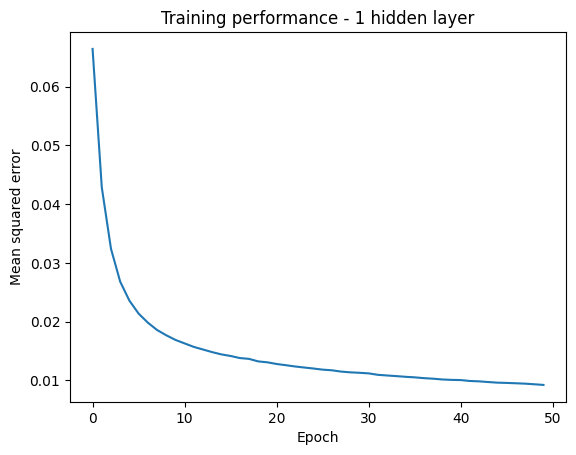

In [ ]:
plt.plot(range(len(epoch_loss)), epoch_loss)
plt.ylabel('Mean squared error')
plt.xlabel('Epoch')
plt.title('Training performance - 1 hidden layer')
#plt.savefig('figures/11_07.png', dpi=300)
plt.show()

**Training loss (MSE) over epochs - 2 hidden layers:**

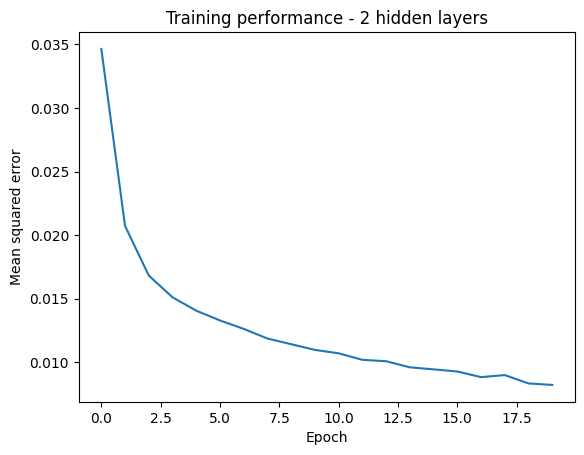

In [ ]:
plt.plot(range(len(epoch_loss_two_layers)), epoch_loss_two_layers)
plt.ylabel('Mean squared error')
plt.xlabel('Epoch')
plt.title('Training performance - 2 hidden layers')
#plt.savefig('figures/11_07.png', dpi=300)
plt.show()

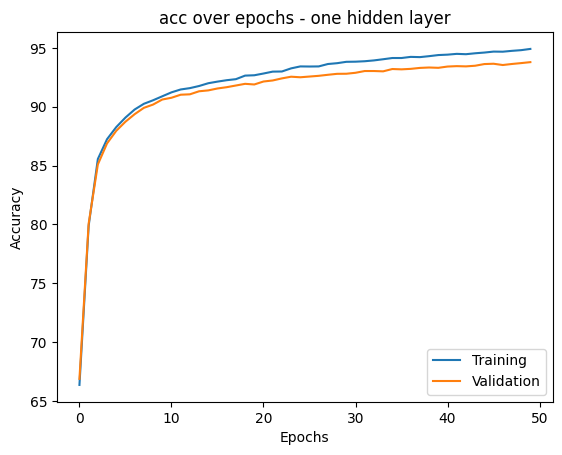

In [ ]:
plt.plot(range(len(epoch_train_acc)), epoch_train_acc,
         label='Training')
plt.plot(range(len(epoch_valid_acc)), epoch_valid_acc,
         label='Validation')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(loc='lower right')
plt.title('acc over epochs - one hidden layer')
#plt.savefig('figures/11_08.png', dpi=300)
plt.show()

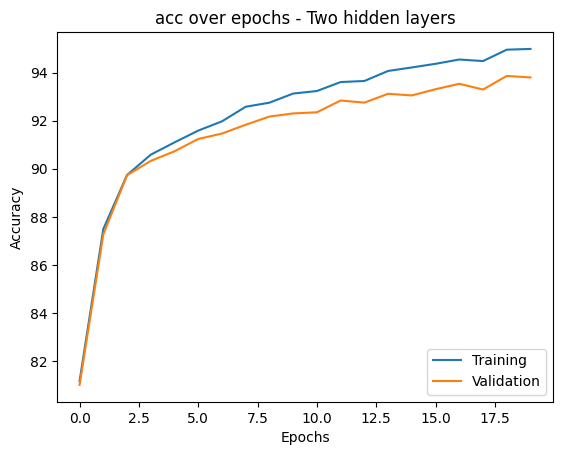

In [ ]:
plt.plot(range(len(epoch_train_acc_two_layers)), epoch_train_acc_two_layers,
         label='Training')
plt.plot(range(len(epoch_valid_acc_two_layers)), epoch_valid_acc_two_layers,
         label='Validation')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(loc='lower right')
plt.title('acc over epochs - Two hidden layers')
#plt.savefig('figures/11_08.png', dpi=300)
plt.show()

**Predictive performance of the two-hidden-layer model (Part 3)**


In [ ]:
# Part 3: Evaluation of the two-hidden-layer ANN using the class architecture

train_mse, train_acc , train_auc= compute_mse_and_acc_and_auc(two_layer_model, X_train, y_train, is_two_layerd=True)
print('Two hidden layers\n')
print('Train set scores:')
print(f'Train accuracy: {train_acc*100:.2f}%')
print(f'Train MSE: {train_mse:.2f}')
print(f'Train AUC: {train_auc*100:.2f}%')
print('')

test_mse, test_acc , test_auc= compute_mse_and_acc_and_auc(two_layer_model, X_test, y_test, is_two_layerd=True)
print('Test set scores:')
print(f'Test accuracy: {test_acc*100:.2f}%')
print(f'Test MSE: {test_mse:.2f}')
print(f'Test AUC: {test_auc*100:.2f}%')

Two hidden layers

Train set scores:
Train accuracy: 94.98%
Train MSE: 0.01
Train AUC: 99.62%

Test set scores:
Test accuracy: 93.79%
Test MSE: 0.01
Test AUC: 99.54%


###Part 4

**PyTorch implementation of a fully connected ANN**

In [ ]:
import torch
from torch import nn, optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
from sklearn.metrics import roc_auc_score

# Redefine PyTorchTwoHiddenLayerMLP to return probabilities (after softmax)
class PyTorchTwoHiddenLayerMLP(nn.Module):
    def __init__(self, num_features, num_hidden_first_layer, num_hidden_second_layer, num_classes):
        super().__init__()
        self.linear_1 = nn.Linear(num_features, num_hidden_first_layer)
        self.linear_2 = nn.Linear(num_hidden_first_layer, num_hidden_second_layer)
        self.linear_out = nn.Linear(num_hidden_second_layer, num_classes)

    def forward(self, x):
        # Hidden Layer 1
        x = self.linear_1(x)
        x = torch.sigmoid(x)

        # Hidden Layer 2
        x = self.linear_2(x)
        x = torch.sigmoid(x)

        # Output Layer: Apply softmax to get probabilities directly
        logits = self.linear_out(x)
        probas = F.softmax(logits, dim=1)
        return probas


# Helper function to compute metrics for PyTorch model (adapted for MSE loss)
def compute_pytorch_metrics(model, X_data, y_data, num_labels, device):
    model.eval() # Set model to evaluation mode
    X_tensor = torch.tensor(X_data, dtype=torch.float32).to(device)
    # y_data remains integer labels for accuracy and AUC calculation
    y_tensor_int = torch.tensor(y_data, dtype=torch.long).to(device)

    all_probas = []
    all_targets_int = []

    with torch.no_grad():
        eval_dataset = TensorDataset(X_tensor, y_tensor_int)
        eval_loader = DataLoader(eval_dataset, batch_size=100)

        correct_predictions = 0
        total_samples = 0

        for features, targets_int in eval_loader:
            features = features.to(device)
            targets_int = targets_int.to(device)

            probas = model(features) # Model now returns probabilities

            predicted_labels = torch.argmax(probas, dim=1)
            correct_predictions += (predicted_labels == targets_int).sum().item()
            total_samples += targets_int.size(0)

            all_probas.append(probas.cpu().numpy())
            all_targets_int.append(targets_int.cpu().numpy())

    accuracy = correct_predictions / total_samples

    # Concatenate all probabilities and integer targets
    full_probas = np.concatenate(all_probas, axis=0)
    full_targets_int = np.concatenate(all_targets_int, axis=0)

    # Convert integer targets to one-hot for AUC calculation
    onehot_targets = np.zeros((full_targets_int.size, num_labels))
    onehot_targets[np.arange(full_targets_int.size), full_targets_int] = 1

    auc = roc_auc_score(onehot_targets, full_probas, multi_class='ovr', average='macro')

    model.train() # Set model back to training mode
    return accuracy, auc

# Training function for PyTorch model
def train_pytorch_mlp_mse_sgd(model, X_train_np, y_train_np, X_valid_np, y_valid_np, num_epochs, learning_rate, batch_size):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)

    criterion = nn.MSELoss(reduction='sum')
    optimizer = optim.SGD(model.parameters(), lr=learning_rate)

    # Convert numpy arrays to PyTorch tensors
    X_train_tensor = torch.tensor(X_train_np, dtype=torch.float32)
    y_train_tensor_int = torch.tensor(y_train_np, dtype=torch.long)

    # Convert y_train_tensor_int to one-hot for MSE Loss
    num_classes = model.linear_out.out_features # Get num_classes from the model
    y_train_tensor_onehot = F.one_hot(y_train_tensor_int, num_classes=num_classes).float()

    # Create TensorDataset and DataLoader for training
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor_onehot) # Use one-hot targets for training
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    epoch_train_acc = []
    epoch_valid_acc = []
    epoch_train_auc = []
    epoch_valid_auc = []
    epoch_loss = []

    for epoch in range(num_epochs):
        model.train() # Set model to training mode
        current_epoch_loss = 0.0

        for batch_idx, (features, targets_onehot) in enumerate(train_loader):
            features = features.to(device)
            targets_onehot = targets_onehot.to(device)

            # Forward pass
            probas = model(features) # Model outputs probabilities
            loss = criterion(probas, targets_onehot) # Calculate MSE with one-hot targets
            loss = loss / batch_size # Normalize loss by batch size
            # Backward and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            current_epoch_loss += loss.item() * features.size(0) # Accumulate weighted loss

        avg_epoch_loss = current_epoch_loss / len(train_dataset)
        epoch_loss.append(avg_epoch_loss)

        # Evaluate on training and validation set (passing original y_train_np/y_valid_np)
        train_acc, train_auc = compute_pytorch_metrics(model, X_train_np, y_train_np, num_classes, device)
        valid_acc, valid_auc = compute_pytorch_metrics(model, X_valid_np, y_valid_np, num_classes, device)

        epoch_train_acc.append(train_acc * 100)
        epoch_valid_acc.append(valid_acc * 100)
        epoch_train_auc.append(train_auc * 100)
        epoch_valid_auc.append(valid_auc * 100)

        print(f'Epoch: {epoch+1:03d}/{num_epochs:03d} '
              f'| Train Loss: {avg_epoch_loss:.4f} '
              f'| Train Acc: {train_acc*100:.2f}% '
              f'| Valid Acc: {valid_acc*100:.2f}% '
              f'| Train AUC: {train_auc*100:.2f}% '
              f'| Valid AUC: {valid_auc*100:.2f}%')

    return epoch_loss, epoch_train_acc, epoch_valid_acc, epoch_train_auc, epoch_valid_auc

# --- Instantiate and train the PyTorch model ---
# Use the same architecture parameters as the numpy TwoHiddenLayerMLP
num_features = 28*28
num_hidden_first_layer = 500
num_hidden_second_layer = 500
num_classes = 10 # MNIST has 10 classes

# Set random seeds for reproducibility
torch.manual_seed(123)
np.random.seed(123)

pytorch_model_mse_sgd = PyTorchTwoHiddenLayerMLP(num_features, num_hidden_first_layer, num_hidden_second_layer, num_classes)

# Define training parameters
num_epochs_pt = 20 # Using 20 epochs like the numpy two-layer model
learning_rate_pt = 0.1
batch_size_pt = 100

print("Starting PyTorch model training with MSE loss and SGD optimizer...")
pytorch_epoch_loss_mse_sgd, pytorch_epoch_train_acc_mse_sgd, pytorch_epoch_valid_acc_mse_sgd, pytorch_epoch_train_auc_mse_sgd, pytorch_epoch_valid_auc_mse_sgd = train_pytorch_mlp_mse_sgd(
    pytorch_model_mse_sgd, X_train, y_train, X_valid, y_valid,
    num_epochs=num_epochs_pt, learning_rate=learning_rate_pt, batch_size=batch_size_pt
)
print("PyTorch model training finished.")

# Optional: Print final test scores for PyTorch model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
pytorch_test_acc_mse_sgd, pytorch_test_auc_mse_sgd = compute_pytorch_metrics(pytorch_model_mse_sgd, X_test, y_test, num_classes, device)
print('\nPyTorch Test set scores (MSE+SGD):')
print(f'Test accuracy: {pytorch_test_acc_mse_sgd*100:.2f}%')
print(f'Test AUC: {pytorch_test_auc_mse_sgd*100:.2f}%')


Starting PyTorch model training with MSE loss and SGD optimizer...
Epoch: 001/020 | Train Loss: 0.8979 | Train Acc: 19.08% | Valid Acc: 18.67% | Train AUC: 92.58% | Valid AUC: 92.56%
Epoch: 002/020 | Train Loss: 0.8878 | Train Acc: 26.12% | Valid Acc: 26.39% | Train AUC: 93.63% | Valid AUC: 93.59%
Epoch: 003/020 | Train Loss: 0.8341 | Train Acc: 29.91% | Valid Acc: 29.58% | Train AUC: 90.58% | Valid AUC: 90.70%
Epoch: 004/020 | Train Loss: 0.6893 | Train Acc: 53.66% | Valid Acc: 54.27% | Train AUC: 94.10% | Valid AUC: 94.16%
Epoch: 005/020 | Train Loss: 0.5132 | Train Acc: 75.09% | Valid Acc: 75.71% | Train AUC: 96.61% | Valid AUC: 96.64%
Epoch: 006/020 | Train Loss: 0.3590 | Train Acc: 83.57% | Valid Acc: 83.64% | Train AUC: 97.85% | Valid AUC: 97.85%
Epoch: 007/020 | Train Loss: 0.2638 | Train Acc: 86.03% | Valid Acc: 85.86% | Train AUC: 98.35% | Valid AUC: 98.33%
Epoch: 008/020 | Train Loss: 0.2171 | Train Acc: 87.69% | Valid Acc: 87.43% | Train AUC: 98.64% | Valid AUC: 98.62%
Epoch

Visualization of training loss, accuracy, and AUC for the PyTorch model

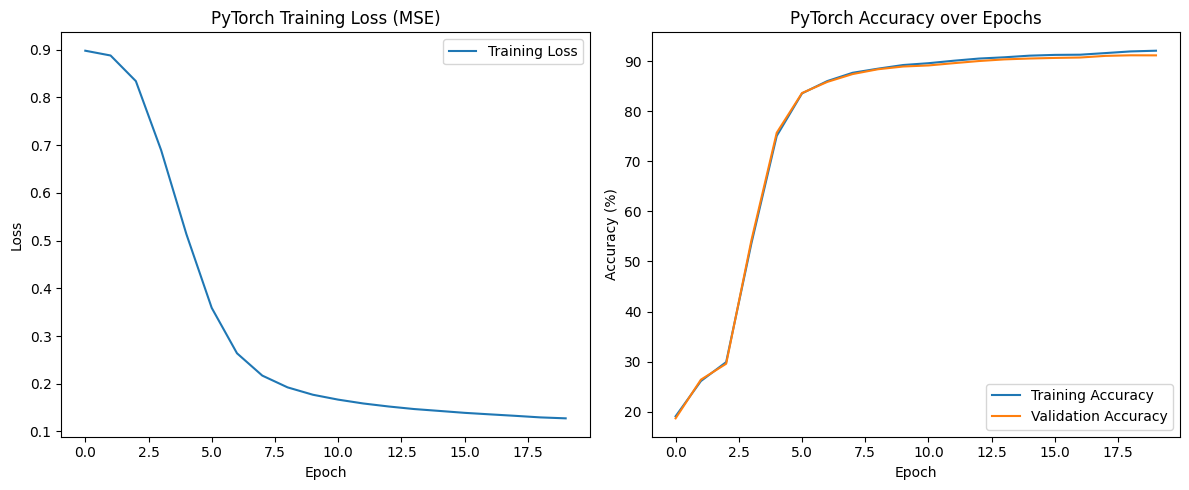

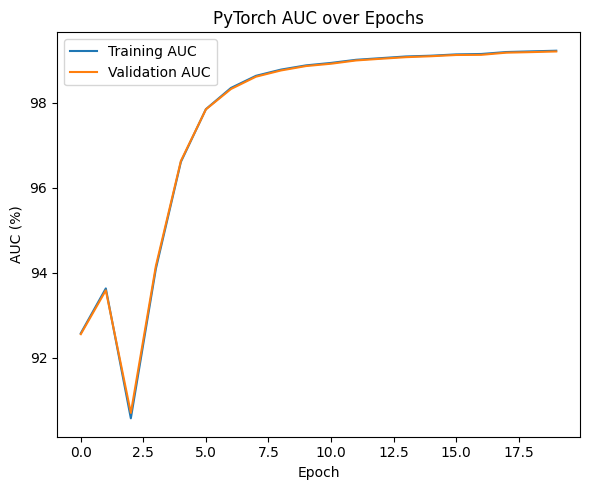

In [ ]:
import matplotlib.pyplot as plt

# Plot Loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(pytorch_epoch_loss_mse_sgd, label='Training Loss')
# For PyTorch, validation loss is not directly calculated in the loop,
# but we can infer it or keep just training loss for this plot
plt.title('PyTorch Training Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(pytorch_epoch_train_acc_mse_sgd, label='Training Accuracy')
plt.plot(pytorch_epoch_valid_acc_mse_sgd, label='Validation Accuracy')
plt.title('PyTorch Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

# Plot AUC
plt.figure(figsize=(6, 5))
plt.plot(pytorch_epoch_train_auc_mse_sgd, label='Training AUC')
plt.plot(pytorch_epoch_valid_auc_mse_sgd, label='Validation AUC')
plt.title('PyTorch AUC over Epochs')
plt.xlabel('Epoch')
plt.ylabel('AUC (%)')
plt.legend()
plt.tight_layout()
plt.show()

**Test set performance comparison: NumPy and PyTorch models**

In [ ]:
# Compute test scores for the 1-layer NumPy model
print('Evaluating 1-layer NumPy model on test set')
one_layer_test_mse, one_layer_test_acc, one_layer_test_auc = compute_mse_and_acc_and_auc(model, X_test, y_test)

print('\n--- Model Comparison (Test Set) ---')
print(f"NumPy (1-layer MLP):\n  Accuracy: {one_layer_test_acc*100:.2f}%\n  MSE Loss: {one_layer_test_mse:.4f}\n  AUC: {one_layer_test_auc*100:.2f}%\n")

print(f"NumPy (2-layer MLP):\n  Accuracy: {test_acc*100:.2f}%\n  MSE Loss: {test_mse:.4f}\n  AUC: {test_auc*100:.2f}%\n")

print(f"PyTorch (2-layer MLP, MSE+SGD):\n  Accuracy: {pytorch_test_acc_mse_sgd*100:.2f}%\n  MSE Loss: Not directly comparable due to different averaging methods, but training loss was {pytorch_epoch_loss_mse_sgd[-1]:.4f}\n  AUC: {pytorch_test_auc_mse_sgd*100:.2f}%\n")

print("Note: The MSE Loss for PyTorch is the average training loss of the last epoch and not directly the test MSE calculated like NumPy models.")


Evaluating 1-layer NumPy model on test set

--- Model Comparison (Test Set) ---
NumPy (1-layer MLP):
  Accuracy: 93.85%
  MSE Loss: 0.0106
  AUC: 99.11%

NumPy (2-layer MLP):
  Accuracy: 93.79%
  MSE Loss: 0.0096
  AUC: 99.54%

PyTorch (2-layer MLP, MSE+SGD):
  Accuracy: 91.43%
  MSE Loss: Not directly comparable due to different averaging methods, but training loss was 0.1275
  AUC: 99.15%

Note: The MSE Loss for PyTorch is the average training loss of the last epoch and not directly the test MSE calculated like NumPy models.


Plot failure cases:

In [ ]:
X_test_subset = X_test[:1000, :]
y_test_subset = y_test[:1000]

_, probas = model.forward(X_test_subset)
test_pred = np.argmax(probas, axis=1)

misclassified_images = X_test_subset[y_test_subset != test_pred][:25]
misclassified_labels = test_pred[y_test_subset != test_pred][:25]
correct_labels = y_test_subset[y_test_subset != test_pred][:25]

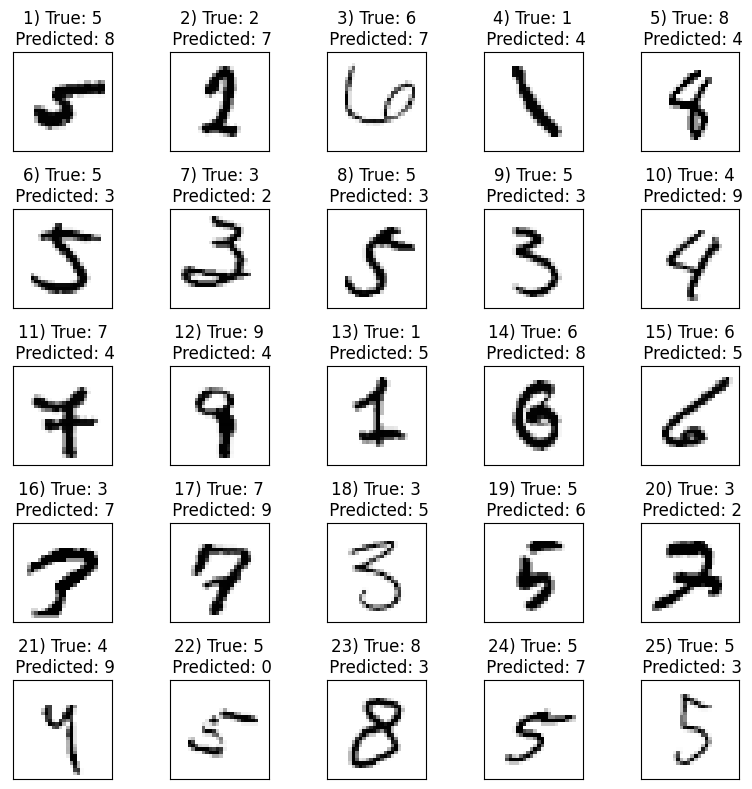

In [ ]:
fig, ax = plt.subplots(nrows=5, ncols=5,
                       sharex=True, sharey=True, figsize=(8, 8))
ax = ax.flatten()
for i in range(25):
    img = misclassified_images[i].reshape(28, 28)
    ax[i].imshow(img, cmap='Greys', interpolation='nearest')
    ax[i].set_title(f'{i+1}) '
                    f'True: {correct_labels[i]}\n'
                    f' Predicted: {misclassified_labels[i]}')

ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()
#plt.savefig('figures/11_09.png', dpi=300)
plt.show()

<br>
<br>

# Training an artificial neural network

...

## Computing the loss function

In [ ]:
Image(filename='figures/11_10.png', width=300)

FileNotFoundError: [Errno 2] No such file or directory: 'figures/11_10.png'

<br>
<br>

## Developing your intuition for backpropagation

...

## Training neural networks via backpropagation

In [ ]:
Image(filename='./figures/11_11.png', width=400)

In [ ]:
Image(filename='figures/11_12.png', width=500)

In [ ]:
Image(filename='figures/11_13.png', width=500)

<br>
<br>

# Convergence in neural networks

In [ ]:
Image(filename='figures/11_14.png', width=500)

<br>
<br>

...

# Summary

...

---

Readers may ignore the next cell.

In [ ]:
! python ../.convert_notebook_to_script.py --input ch11.ipynb --output ch11.py

In [ ]:
one_layer_test_mse, one_layer_test_acc, one_layer_test_auc = compute_mse_and_acc_and_auc(model, X_test, y_test)

In [ ]:
final_accuracies = {
    '1-layer NumPy': {
        'Train': epoch_train_acc[-1],
        'Validation': epoch_valid_acc[-1],
        'Test': one_layer_test_acc * 100
    },
    '2-layer NumPy': {
        'Train': epoch_train_acc_two_layers[-1],
        'Validation': epoch_valid_acc_two_layers[-1],
        'Test': test_acc * 100
    },
    'PyTorch (2-layer, MSE+SGD)': {
        'Train': pytorch_epoch_train_acc_mse_sgd[-1],
        'Validation': pytorch_epoch_valid_acc_mse_sgd[-1],
        'Test': pytorch_test_acc_mse_sgd * 100
    }
}

print("Final Accuracies (in %):")
for model_name, accs in final_accuracies.items():
    print(f"  {model_name}:")
    for acc_type, value in accs.items():
        print(f"    {acc_type}: {value:.2f}%")

Final Accuracies (in %):
  1-layer NumPy:
    Train: 94.91%
    Validation: 93.79%
    Test: 93.85%
  2-layer NumPy:
    Train: 94.98%
    Validation: 93.80%
    Test: 93.79%
  PyTorch (2-layer, MSE+SGD):
    Train: 92.09%
    Validation: 91.16%
    Test: 91.43%


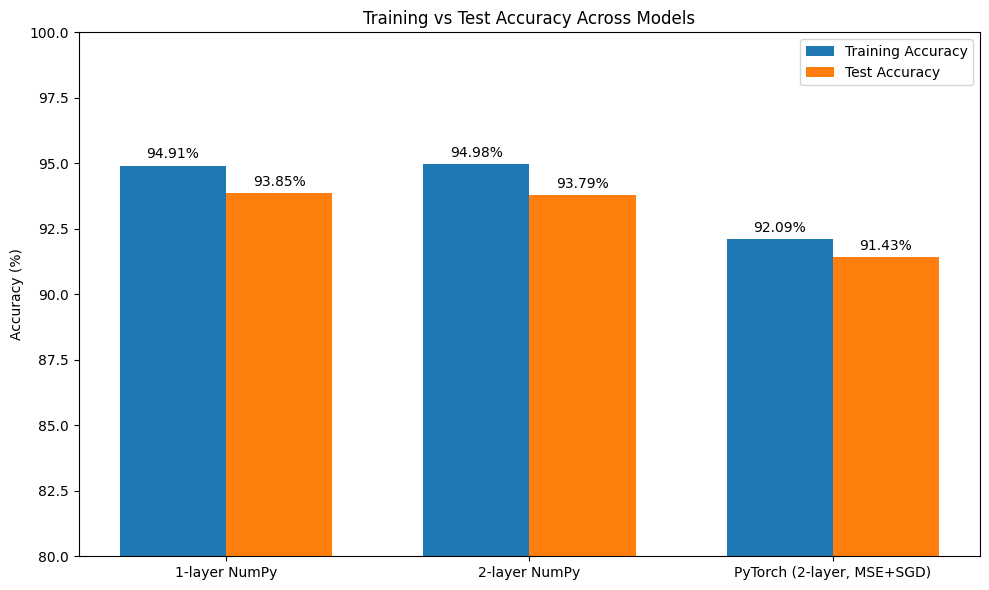

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

model_names = list(final_accuracies.keys())

train_accuracies = [final_accuracies[name]['Train'] for name in model_names]
test_accuracies = [final_accuracies[name]['Test'] for name in model_names]

x = np.arange(len(model_names))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, train_accuracies, width, label='Training Accuracy')
rects2 = ax.bar(x + width/2, test_accuracies, width, label='Test Accuracy')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Accuracy (%)')
ax.set_title('Training vs Test Accuracy Across Models')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend()
ax.set_ylim(80, 100) # Set y-axis limits to better show differences

def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

### Summary of Model Performance

Comparing the training and test accuracies across the three models:

*   **1-layer NumPy MLP**: Achieved strong performance with a training accuracy of approximately 94.91% and a test accuracy of about 93.85%. This indicates good generalization to unseen data.

*   **2-layer NumPy MLP**: Also showed robust performance, with a training accuracy of roughly 94.98% and a test accuracy of around 93.79%. Interestingly, adding a second hidden layer and more parameters did not significantly improve the test accuracy over the 1-layer NumPy model, suggesting that for this specific dataset and hyperparameters, a single hidden layer was sufficient or potential overfitting started to occur with more complexity (though the accuracies are very close).

*   **PyTorch (2-layer, MSE+SGD)**: This model had a training accuracy of approximately 92.09% and a test accuracy of about 91.43%. While still performing well, it shows slightly lower accuracies compared to both NumPy implementations. This could be attributed to differences in initialization, optimization specifics (SGD in PyTorch vs. the custom implementation in NumPy), or how the MSE loss is handled in PyTorch's `MSELoss` (which might be scaled differently compared to the custom `mse_loss` function in NumPy). The AUC scores for all models are high, indicating good discriminative power across classes.

In summary, both NumPy implementations (1-layer and 2-layer) performed very similarly and slightly better than the PyTorch implementation under the given conditions. The additional hidden layer in the NumPy 2-layer model did not yield a notable improvement over its 1-layer counterpart.